# Project 1: Hospital Performance Analysis

**Author:** M. Varalakshmi
**Dataset:** FY 2026 CMS Hospital Readmissions Reduction Program
**Tools:** Python — pandas, matplotlib, seaborn

## Objective
Analyse hospital readmission performance across the USA using real government data to identify high-risk conditions and states.

step 1 : loading required libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

step 2: uploading dataset

In [4]:
df = pd.read_csv('FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv')
df.head()

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


Step 3: Understanding the Dataset

In [5]:
df.shape

(18330, 12)

In [6]:
df.columns

Index(['Facility Name', 'Facility ID', 'State', 'Measure Name',
       'Number of Discharges', 'Footnote', 'Excess Readmission Ratio',
       'Predicted Readmission Rate', 'Expected Readmission Rate',
       'Number of Readmissions', 'Start Date', 'End Date'],
      dtype='object')

In [7]:
df.dtypes

,0
Facility Name,object
Facility ID,int64
State,object
Measure Name,object
Number of Discharges,float64
Footnote,float64
Excess Readmission Ratio,float64
Predicted Readmission Rate,float64
Expected Readmission Rate,float64
Number of Readmissions,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18330 non-null  object 
 1   Facility ID                 18330 non-null  int64  
 2   State                       18330 non-null  object 
 3   Measure Name                18330 non-null  object 
 4   Number of Discharges        8242 non-null   float64
 5   Footnote                    6987 non-null   float64
 6   Excess Readmission Ratio    11720 non-null  float64
 7   Predicted Readmission Rate  11720 non-null  float64
 8   Expected Readmission Rate   11720 non-null  float64
 9   Number of Readmissions      11720 non-null  object 
 10  Start Date                  18330 non-null  object 
 11  End Date                    18330 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 1.7+ MB


In [9]:
df.describe()

,Facility ID,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate
count,18330.000000,8242.000000,6987.000000,11720.000000,11720.000000,11720.000000
mean,262031.979378,283.416282,4.550308,1.001777,14.981461,14.947978
std,164868.122655,270.929023,6.181702,0.082050,4.763655,4.620865
min,10001.000000,0.000000,1.000000,0.469800,1.908000,3.087600
25%,110069.000000,117.000000,1.000000,0.958200,12.529550,12.623750
50%,250048.000000,198.000000,5.000000,0.997300,15.860150,15.856550
75%,390138.000000,358.000000,5.000000,1.042300,18.418500,18.500925
max,670342.000000,3672.000000,29.000000,1.629700,28.164300,26.865400


In [10]:
df.isnull().sum()

,0
Facility Name,0
Facility ID,0
State,0
Measure Name,0
Number of Discharges,10088
Footnote,11343
Excess Readmission Ratio,6610
Predicted Readmission Rate,6610
Expected Readmission Rate,6610
Number of Readmissions,6610


Step 4: Data Cleaning

In [11]:
df = df.drop(columns=['Footnote'])
df.shape

(18330, 11)

In [12]:
df = df.dropna(subset=['Excess Readmission Ratio'])
df.shape

(11720, 11)

Convert Number of Readmissions to Numeric

In [13]:
df['Number of Readmissions'] = pd.to_numeric(df['Number of Readmissions'], errors='coerce')
df['Number of Readmissions'].dtype

dtype('float64')

Convert Dates to Proper Format

In [14]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df[['Start Date', 'End Date']].dtypes

,0
Start Date,datetime64[ns]
End Date,datetime64[ns]


Fill Missing Number of Discharges

In [15]:
median_discharges = df['Number of Discharges'].median()
print('Median discharges:', median_discharges)

df['Number of Discharges'] = df['Number of Discharges'].fillna(median_discharges)

Median discharges: 203.0


Confirm Everything is Clean

In [16]:
df.isnull().sum()

,0
Facility Name,0
Facility ID,0
State,0
Measure Name,0
Number of Discharges,0
Excess Readmission Ratio,0
Predicted Readmission Rate,0
Expected Readmission Rate,0
Number of Readmissions,3683
Start Date,0


In [17]:
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())

Shape: (11720, 11)

Missing values:
Facility Name                    0
Facility ID                      0
State                            0
Measure Name                     0
Number of Discharges             0
Excess Readmission Ratio         0
Predicted Readmission Rate       0
Expected Readmission Rate        0
Number of Readmissions        3683
Start Date                       0
End Date                         0
dtype: int64


Step 5: Exploratory Data Analysis

In [18]:
df['Measure Name'].value_counts()

,count
Measure Name,
READM-30-PN-HRRP,2715
READM-30-HF-HRRP,2621
READM-30-COPD-HRRP,2323
READM-30-AMI-HRRP,1736
READM-30-HIP-KNEE-HRRP,1447
READM-30-CABG-HRRP,878


In [19]:
df['State'].nunique()

51

In [20]:
df['State'].value_counts().head(10)

,count
State,
CA,1038
TX,898
FL,771
PA,545
NY,520
IL,491
OH,481
MI,362
GA,346


In [21]:
df.groupby('Measure Name')['Excess Readmission Ratio'].mean().sort_values(ascending=False)

,Excess Readmission Ratio
Measure Name,
READM-30-HIP-KNEE-HRRP,1.003985
READM-30-CABG-HRRP,1.001789
READM-30-AMI-HRRP,1.001755
READM-30-PN-HRRP,1.001486
READM-30-HF-HRRP,1.001439
READM-30-COPD-HRRP,1.001133


In [22]:
high_risk = (df['Excess Readmission Ratio'] > 1.0).sum()
total = len(df)
percentage = (high_risk / total) * 100

print(f'High risk hospitals: {high_risk}')
print(f'Total records: {total}')
print(f'Percentage at risk: {percentage:.1f}%')

High risk hospitals: 5643
Total records: 11720
Percentage at risk: 48.1%


Step 6: Visualizations

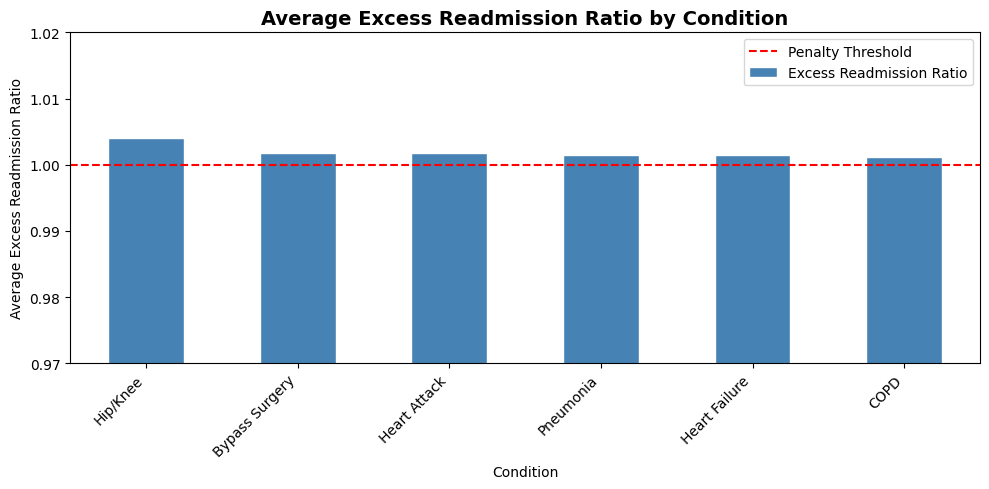

In [24]:
# Readable condition names
condition_map = {
    'READM-30-AMI-HRRP'      : 'Heart Attack',
    'READM-30-HF-HRRP'       : 'Heart Failure',
    'READM-30-PN-HRRP'       : 'Pneumonia',
    'READM-30-COPD-HRRP'     : 'COPD',
    'READM-30-HIP-KNEE-HRRP' : 'Hip/Knee',
    'READM-30-CABG-HRRP'     : 'Bypass Surgery'
}

# Add readable names as new column
df['Condition'] = df['Measure Name'].map(condition_map)

# Calculate average ERR by condition
condition_avg = df.groupby('Condition')['Excess Readmission Ratio'].mean().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 5))
condition_avg.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Average Excess Readmission Ratio by Condition', fontsize=14, fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Average Excess Readmission Ratio')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=1.0, color='red', linestyle='--', label='Penalty Threshold')
plt.ylim(0.97, 1.02)  # zoom in to see differences
plt.legend()
plt.tight_layout()
plt.show()

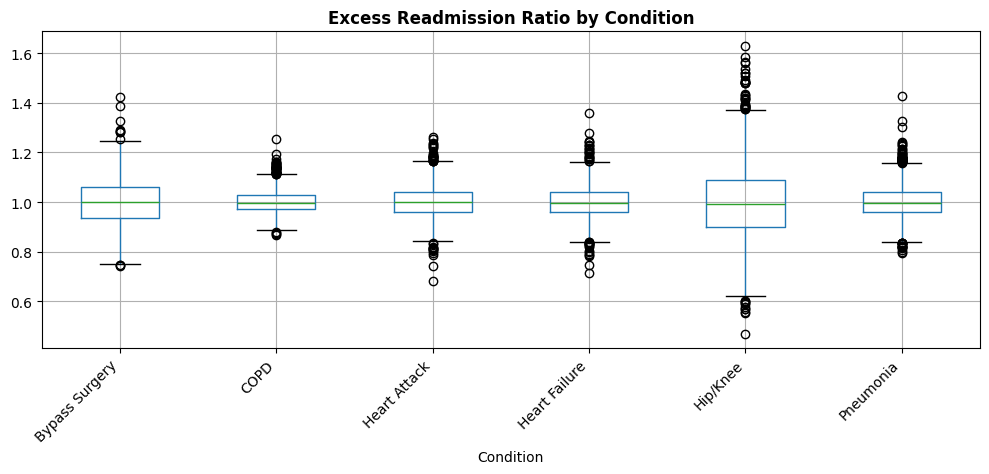

In [25]:
df.boxplot(column='Excess Readmission Ratio', by='Condition', figsize=(10,5))
plt.title('Excess Readmission Ratio by Condition', fontweight='bold')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Conclusion

- 48.1% of hospital-condition pairs exceed the CMS penalty threshold
- Hip/Knee Replacement shows the highest variation in readmission ratios
- All conditions average above the penalty threshold of 1.0